In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ugdatalab.models.galaxy_zoo import GalaxyZooData, GalaxyZooImages
from ugdatalab.models.galaxy_zoo.constants import (
    N_LABELS,
    LABEL_COLUMNS,
    LABEL_DESCRIPTIVE,
    LABEL_TREE,
    _GALAXY_ZOO_SCHEMA,
)
from ugdatalab.models.galaxy_zoo.images import _load_image

import plotters

/home/ikaros/projects/ay-128/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Galaxy Image Classification — Data Exploration

In this lab we build convolutional neural networks (CNNs) to morphologically classify galaxies from Sloan Digital Sky Survey (SDSS) images, using labels from the Galaxy Zoo 2 (GZ2) citizen-science project (Willett et al. 2013). Each galaxy has 37 classification labels — continuous values in $[0, 1]$ representing the fraction of human classifiers who assigned a particular morphological feature (smooth, spiral, bar, merger, etc.). The labels are organized in a hierarchical decision tree: for example, "number of spiral arms" is only asked for galaxies that were identified as having spiral structure.

The goals of this notebook are:
1. Load and explore the training set (images + labels)
2. Plot label distributions and prototype images to understand the classification scheme
3. Compute the label correlation matrix to identify dependencies and redundancies
4. Estimate memory requirements for the full image dataset

## Background — why morphology and why mergers?

### Why astronomers care about morphological classification (Conselice 2014)

Galaxy morphology is the lowest-cost observational tracer of a galaxy's *dynamical state* and *formation history*. The Hubble sequence is more than a taxonomy: it separates pressure-supported, gas-poor, red, quiescent **ellipticals** (E0–E7) from rotation-supported, gas-rich, blue, star-forming **disks** (Sa–Sd, Irr), and the position of a galaxy along the sequence correlates with its star-formation rate, stellar mass, environment, dark-matter halo mass, and merger history. Conselice (2014, ARA&A) shows that the morphology–environment relation, the morphology–density relation, and the bimodality of the colour-magnitude diagram all point to morphology being a *consequence* of a galaxy's assembly path rather than an arbitrary label. Quantifying morphology over very large samples — only possible at the scale of an all-sky survey like SDSS — therefore lets us reconstruct the evolution of the galaxy population statistically, even when we cannot follow any individual galaxy through cosmic time.

### Why systematically search for mergers (Lotz et al. 2011; Rodríguez-Gómez et al. 2015)

Galaxy mergers are the single most violent event in a galaxy's life. They drive starbursts, fuel AGN, scramble disks into spheroids, redistribute angular momentum, trigger gas inflows that build pseudobulges, and — in the case of major mergers — are believed to be the dominant channel for forming massive ellipticals (the "merger hypothesis" of Toomre & Toomre 1972). The cosmic merger rate as a function of redshift, mass, and mass ratio is therefore a fundamental constraint on hierarchical structure formation. Lotz et al. (2011, ApJ 742, 103) measure the merger rate by counting *morphologically disturbed* systems (using non-parametric indicators like Gini–$M_{20}$ and CAS asymmetry) and dividing by a theoretical or simulation-calibrated visibility timescale $T_{\mathrm{obs}}$ — turning a snapshot fraction into a rate per Gyr. Rodríguez-Gómez et al. (2015, MNRAS 449, 49) instead trace the merger rate directly from the **Illustris** cosmological hydrodynamical simulation by counting subhalo coalescences. Both papers agree that the merger rate evolves strongly with redshift but disagree on normalisation by factors of a few — a discrepancy whose resolution requires *exactly* the kind of large-sample, well-calibrated, morphology-based merger fractions that Galaxy Zoo and this lab produce. Historically, mergers have been identified by **visual inspection** (the original Toomre catalogue), by **kinematic signatures** (counter-rotation, kinematic misalignments), and by **non-parametric morphology statistics** (Gini–$M_{20}$, CAS, multi-mode/intensity/deviation $\{M, I, D\}$); the CNN we will train in this lab is the modern, scalable extension of the visual approach.

### Galaxy Zoo classification scheme

GZ2 presents each galaxy as an SDSS three-colour cutout and asks volunteers a series of branching questions: "Is the galaxy smooth, does it have features/a disk, or is it a star/artefact?" — and, depending on the answer, follow-up questions about edge-on geometry, bar presence, spiral arms, bulge prominence, roundness, and odd features. The decision tree mirrors the astrophysical structure of the Hubble sequence and is reproduced in full in Willett et al. (2013) Figure 1. Because each volunteer answers each branch at most once, the 37 vote-fraction "labels" we work with are the *fraction* of volunteers who selected each leaf, normalised so that siblings within a question sum to the parent fraction. This makes the labels continuous in $[0, 1]$ rather than categorical — which is why we treat the task as multi-label regression with RMSE loss rather than a softmax classification.

> **Screenshots from Galaxy Zoo (place here in the report).** Per the lab manual we visited https://www.zooniverse.org/projects/zookeeper/galaxy-zoo/ and classified a handful of galaxies. We include one screenshot of an obvious *spiral with clear arm structure* (e.g. a face-on Sb/Sc grand-design spiral) and one of a *morphologically smooth* galaxy (a featureless elliptical viewed at moderate inclination). The classifier interface itself confirms that the relevant astrophysical distinctions — disk vs. spheroid, arm count, bar presence — are exactly the ones the GZ2 tree is designed to probe. The hands-on classification experience also surfaces the practical sources of ambiguity that show up later in the CNN's residuals: low-surface-brightness companions, edge-on disks whose dust lane is unresolved, and faint tidal features that read as either "merger" or "irregular" depending on contrast.

### Willett et al. 2013 — explicit answers to the lab-manual questions

The numbered questions below are the magenta-highlighted prompts in the lab manual. Page/section/Figure citations refer to Willett et al. (2013, MNRAS 435, 2835), hereafter W13.

1. **What cuts were applied to SDSS DR7 to construct the GZ2 sample, and how many galaxies does GZ2 contain?**
   GZ2 selects extended sources from SDSS DR7 Legacy imaging with Petrosian magnitude $m_r < 17.0$ (later extended to $m_r < 17.77$ for a "Stripe 82" deep sample), Petrosian half-light radius $r_{\mathrm{Petro,90}} > 3''$, and removes objects flagged as saturated, blended, or as known stars. After these cuts the **main sample contains 304,122 galaxies**, with an additional $\sim 16{,}000$ in the Stripe-82 deeper subset (W13 §2.1, Table 1). The classifications were collected over $\sim 14$ months from $\sim 84{,}000$ volunteers, totalling $\sim 16$ million individual votes. *The Kaggle training set we use is a $\sim 61{,}578$-galaxy subset, balanced across morphological types for the 2014 Galaxy Zoo Challenge.*

2. **Describe the panel layout of galaxy images in GZ2. What are the angular and physical dimensions?**
   Each panel is a colour-composite SDSS $gri$ JPEG cutout, scaled to a fixed angular size of $\mathbf{0.024 \times r_{\mathrm{Petro,90}}}$ arcseconds per pixel and rendered at $424 \times 424$ pixels. This corresponds to an angular field of view of $\sim 1.7\, r_{\mathrm{Petro,90}}$ on a side (W13 §2.2). At the median GZ2 redshift $z \sim 0.07$ and assuming $H_0 = 70$ km/s/Mpc, $1''$ corresponds to $\sim 1.35$ kpc, so a typical $r_{\mathrm{Petro,90}} \sim 5''$ galaxy spans $\sim 7$ kpc and the cutout side is $\sim 12$ kpc. The physical scale therefore tracks the galaxy's apparent size rather than being fixed in kpc — which is why higher-$z$ galaxies fill less of the frame.

3. **Describe the GZ2 classification scheme. How many questions per galaxy?**
   The decision tree has **11 questions** (Q1–Q11) with **37 leaf answers** total. The first three questions are asked of every galaxy; later questions are gated by earlier answers (e.g. Q9 about the bulge shape of an edge-on disk is only asked if Q2 = "edge-on yes"). The full tree is W13 Figure 1 and Table 2.

4. **How did the classification scheme change from GZ1 to GZ2?**
   GZ1 asked a single five-way question (elliptical / clockwise spiral / anti-clockwise spiral / edge-on / star). GZ2 replaces this with the 11-question, 37-answer hierarchical tree that breaks each high-level class into sub-classes, adding detail about bar presence, arm winding and count, bulge prominence, and odd features (W13 §1, §2.3).

5. **How does GZ2 decide the ordering of galaxies shown to users?**
   Galaxies are served in **random order**, with the constraint that no user sees the same galaxy twice and that each galaxy is preferentially shown to users until it accumulates a target number of independent classifications (W13 §2.2).

6. **How many unique classifications does a typical galaxy receive?**
   A typical galaxy receives **$\sim 40$–$50$ independent classifications**, with a minimum of $\sim 15$ and a long tail to $> 100$ for galaxies in the Stripe-82 deep sample (W13 §3.1, Figure 4).

7. **What steps were taken to address unreliable classifications?**
   Three layers of cleaning. (a) Users with anomalously low agreement with the consensus on a "training" subset of well-known objects are down-weighted. (b) Per-galaxy, the vote fractions are **debiased** for the apparent-size and apparent-magnitude trends that arise when the same intrinsic galaxy is harder to classify at lower S/N. (c) Vote fractions for child questions are renormalised by the parent vote fraction so that siblings always sum to the parent (W13 §3.2–3.3).

8. **What is the primary reason for the apparent redshift evolution of morphological type in raw GZ2 fractions?**
   The dominant effect is **classification bias** from decreasing angular resolution and surface-brightness dimming at higher redshift: a real spiral at $z = 0.2$ subtends fewer pixels and has fainter arms than the same galaxy would at $z = 0.02$, so volunteers preferentially vote "smooth" for it. This produces an *apparent* drift toward earlier types with redshift even when the intrinsic galaxy population is unchanged (W13 §4.1).

9. **Briefly describe how GZ2 corrects for classification bias. What is "classification bias"?**
   "Classification bias" is the systematic shift of vote fractions with apparent magnitude and angular size driven by resolution/surface-brightness effects, not real morphological evolution. W13 correct it by binning galaxies in $(M_r, R_{50})$ and fitting an empirical correction that maps the observed vote fractions at each $(M_r, R_{50})$ back onto the vote fractions of a "well-resolved" reference sample at low redshift (W13 §4–§5, Figures 8–10). The corrected vote fractions are the ones we use as labels.

10. **Why are higher-redshift galaxies in GZ2 more likely to be classified as mergers?**
    Two reinforcing effects. (i) At higher $z$, surface-brightness dimming and lower angular resolution make low-contrast disturbances harder to see and easier to misread as truly chaotic morphology, biasing the "merger" vote upward. (ii) The intrinsic galaxy *merger rate* genuinely rises with redshift roughly as $(1+z)^{2-3}$ (Lotz et al. 2011, Rodríguez-Gómez et al. 2015), so even after correcting for resolution there is a real excess of merging systems at earlier epochs. The W13 debiasing handles (i); (ii) is a physical result.

11. **Why do GZ2 classifications use boolean yes/no questions for a finite set of possible classifications, yet report floats $[0, 1]$?**
    Each *individual* volunteer answers a categorical (boolean per branch) question. The reported "label" is the **fraction of volunteers** who selected that answer — a number in $[0, 1]$ that estimates the posterior probability of that morphological feature given the population of human classifiers. The vote fraction encodes both the certainty of the classification and the genuine ambiguity of intermediate-type galaxies (e.g. an S0/Sa boundary case may get $40\%$ smooth, $60\%$ features/disk votes). This is why we train against the vote fractions directly as a multi-label regression rather than thresholding to hard categorical labels.

12. **Significant differences between GZ2 and other morphological catalogs.**
    Earlier large-area catalogs were either *expert-classified* (Nair & Abraham 2010 — NA10 — a $\sim 14{,}000$-galaxy catalog with single-expert T-types on a 13-class scale) or *automatically classified* using non-parametric morphological statistics (Gini, $M_{20}$, CAS, Sérsic-index fits; e.g. Lotz et al. 2008). GZ2 differs from both in three significant ways: (a) **sample size** — $\sim 304{,}000$ galaxies, $\sim 20\times$ NA10 and an order of magnitude larger than any expert catalog; (b) **statistical robustness** — each galaxy has $\sim 40$–$50$ independent classifications, so the *uncertainty* on each vote fraction is quantified, unlike a single-expert T-type or a deterministic Gini–$M_{20}$ value; (c) **richer feature resolution** along selected decision-tree branches (bar / spiral / bulge / odd) at the cost of coarser top-level granularity than NA10's T-types. W13 §6 (Figure 16) shows that GZ2 vote fractions correlate strongly with NA10 T-types — the citizen-science labels carry the same morphological information as expert classifications, but at a scale that automated and expert pipelines cannot match.

## Task 5 — Load the Training Set

The training set consists of two files:
- `data/training_classifications.csv` — a CSV table with GalaxyID and 37 label columns
- `data/training_images/` — a directory of JPEG images named `{GalaxyID}.jpg`

Each image is an SDSS $gri$-composite cutout centered on the galaxy, displayed as an RGB image. We first load the labels, inspect the table, and then display a sample of 25 random images to get a visual sense of the data.

In [2]:
CSV_PATH = Path("data/training_classifications.csv")
IMAGE_DIR = Path("data/training_images")

gz = GalaxyZooData(CSV_PATH)
print(f"Number of galaxies: {len(gz)}")
print(f"Number of labels: {N_LABELS}")
print(f"Image dimensions: {_load_image(IMAGE_DIR / f'{gz.galaxy_ids[0]}.jpg').shape}")
display(gz.data)

Number of galaxies: 61578
Number of labels: 37
Image dimensions: (424, 424, 3)


,GalaxyID,Class1.1,Class1.2,Class1.3,Class2.1,Class2.2,Class3.1,Class3.2,Class4.1,Class4.2,...,Class9.3,Class10.1,Class10.2,Class10.3,Class11.1,Class11.2,Class11.3,Class11.4,Class11.5,Class11.6
0,100008,0.383147,0.616853,0.000000,0.000000,0.616853,0.038452,0.578401,0.418398,0.198455,...,0.000000,0.279952,0.138445,0.000000,0.000000,0.092886,0.000000,0.000000,0.0,0.325512
1,100023,0.327001,0.663777,0.009222,0.031178,0.632599,0.467370,0.165229,0.591328,0.041271,...,0.018764,0.000000,0.131378,0.459950,0.000000,0.591328,0.000000,0.000000,0.0,0.000000
2,100053,0.765717,0.177352,0.056931,0.000000,0.177352,0.000000,0.177352,0.000000,0.177352,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
3,100078,0.693377,0.238564,0.068059,0.000000,0.238564,0.109493,0.129071,0.189098,0.049466,...,0.000000,0.094549,0.000000,0.094549,0.189098,0.000000,0.000000,0.000000,0.0,0.000000
4,100090,0.933839,0.000000,0.066161,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61573,999948,0.510379,0.489621,0.000000,0.059207,0.430414,0.000000,0.430414,0.226257,0.204157,...,0.000000,0.226257,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.226257
61574,999950,0.901216,0.098784,0.000000,0.000000,0.098784,0.000000,0.098784,0.000000,0.098784,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
61575,999958,0.202841,0.777376,0.019783,0.116962,0.660414,0.067245,0.593168,0.140022,0.520391,...,0.000000,0.000000,0.090673,0.049349,0.000000,0.067726,0.000000,0.000000,0.0,0.072296
61576,999964,0.091000,0.909000,0.000000,0.045450,0.863550,0.022452,0.841098,0.795330,0.068220,...,0.000000,0.068398,0.318132,0.408799,0.227464,0.408799,0.090668,0.023065,0.0,0.045334


### Random sample of training images

We display 28 random images to get a qualitative sense of the dataset. These are RGB composites from SDSS $gri$ bands — the $g$ filter ($\sim 475$ nm) maps to blue, $r$ ($\sim 623$ nm) to green, and $i$ ($\sim 763$ nm) to red. This color mapping encodes astrophysical information: blue galaxies are dominated by young, hot OB stars and active star formation (typically late-type spirals and irregulars), while red galaxies are dominated by older, cooler stellar populations on the red giant branch (typically early-type ellipticals and lenticulars). The color bimodality visible even by eye — some cutouts clearly blue, others clearly red — reflects the well-established bimodality in the galaxy color-magnitude diagram between the blue cloud (star-forming disks) and the red sequence (quiescent spheroids).

The GZ2 sample spans redshifts $z \sim 0.02$--$0.25$, so most galaxies appear as small, centrally-concentrated objects against a dark sky background. The $424 \times 424$ pixel cutout corresponds to a fixed angular size on the sky, meaning that higher-redshift galaxies occupy fewer pixels and show less resolved structure. The large amount of empty border around each galaxy is wasted pixels that we will crop in NB 02 to focus the CNN on the galaxy itself.

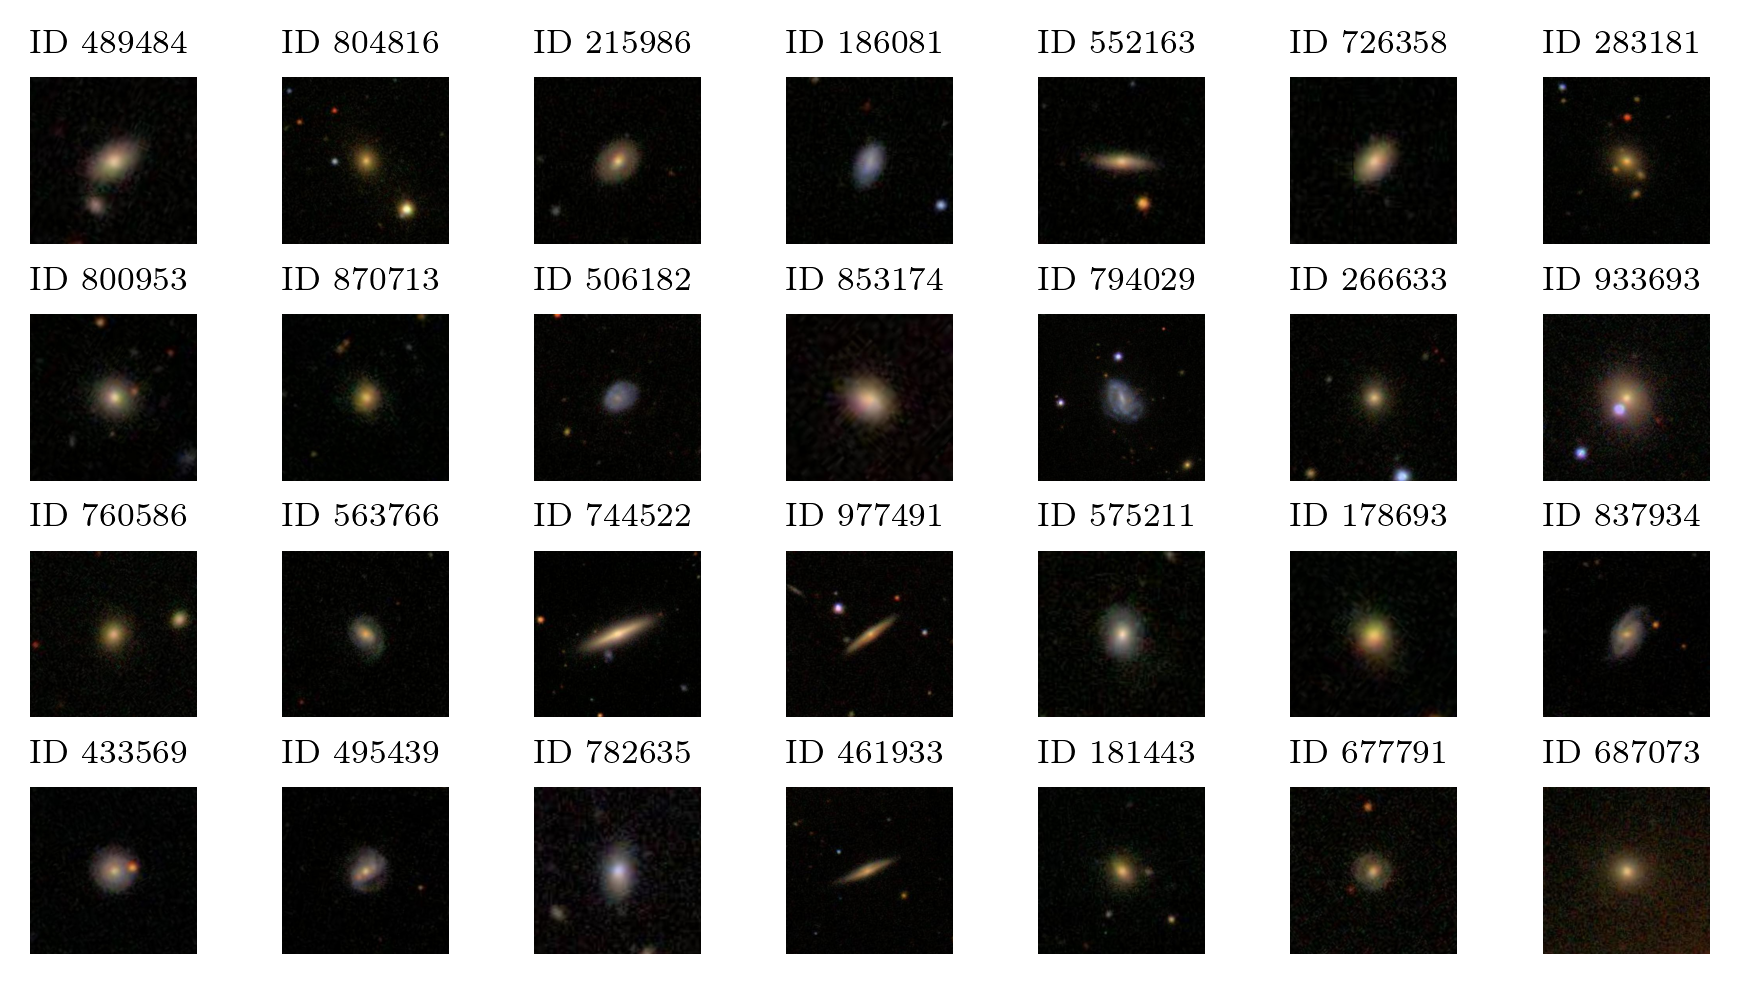

In [3]:
# Load a small batch of raw images for display
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(gz), size=28, replace=False)
sample_images = np.stack([
    _load_image(IMAGE_DIR / f"{gz.galaxy_ids[i]}.jpg") for i in sample_idx
])
sample_ids = gz.galaxy_ids[sample_idx]

axes = plotters.plot_random_images(sample_images, sample_ids, 28, 42)
plt.show()

## Task 6 — Label Distributions

The 37 GZ2 labels represent *vote fractions* — the proportion of classifiers who selected each answer to each question. They are organized hierarchically: Question 1 (smooth vs. features vs. star?) gates whether Question 2 (edge-on?) is asked, which gates further questions, and so on. This hierarchical structure has important consequences:

- Labels for "deeper" questions (e.g., number of spiral arms) are naturally concentrated near zero because most galaxies never reached that question.
- Labels for top-level questions (smooth, features/disk) are more uniformly distributed.
- Some labels are mutually exclusive within a question (e.g., Class1.1 + Class1.2 + Class1.3 $\approx 1$).

We plot normalized histograms of all 37 labels, using the descriptive names from Willett et al. 2013 Table 2.

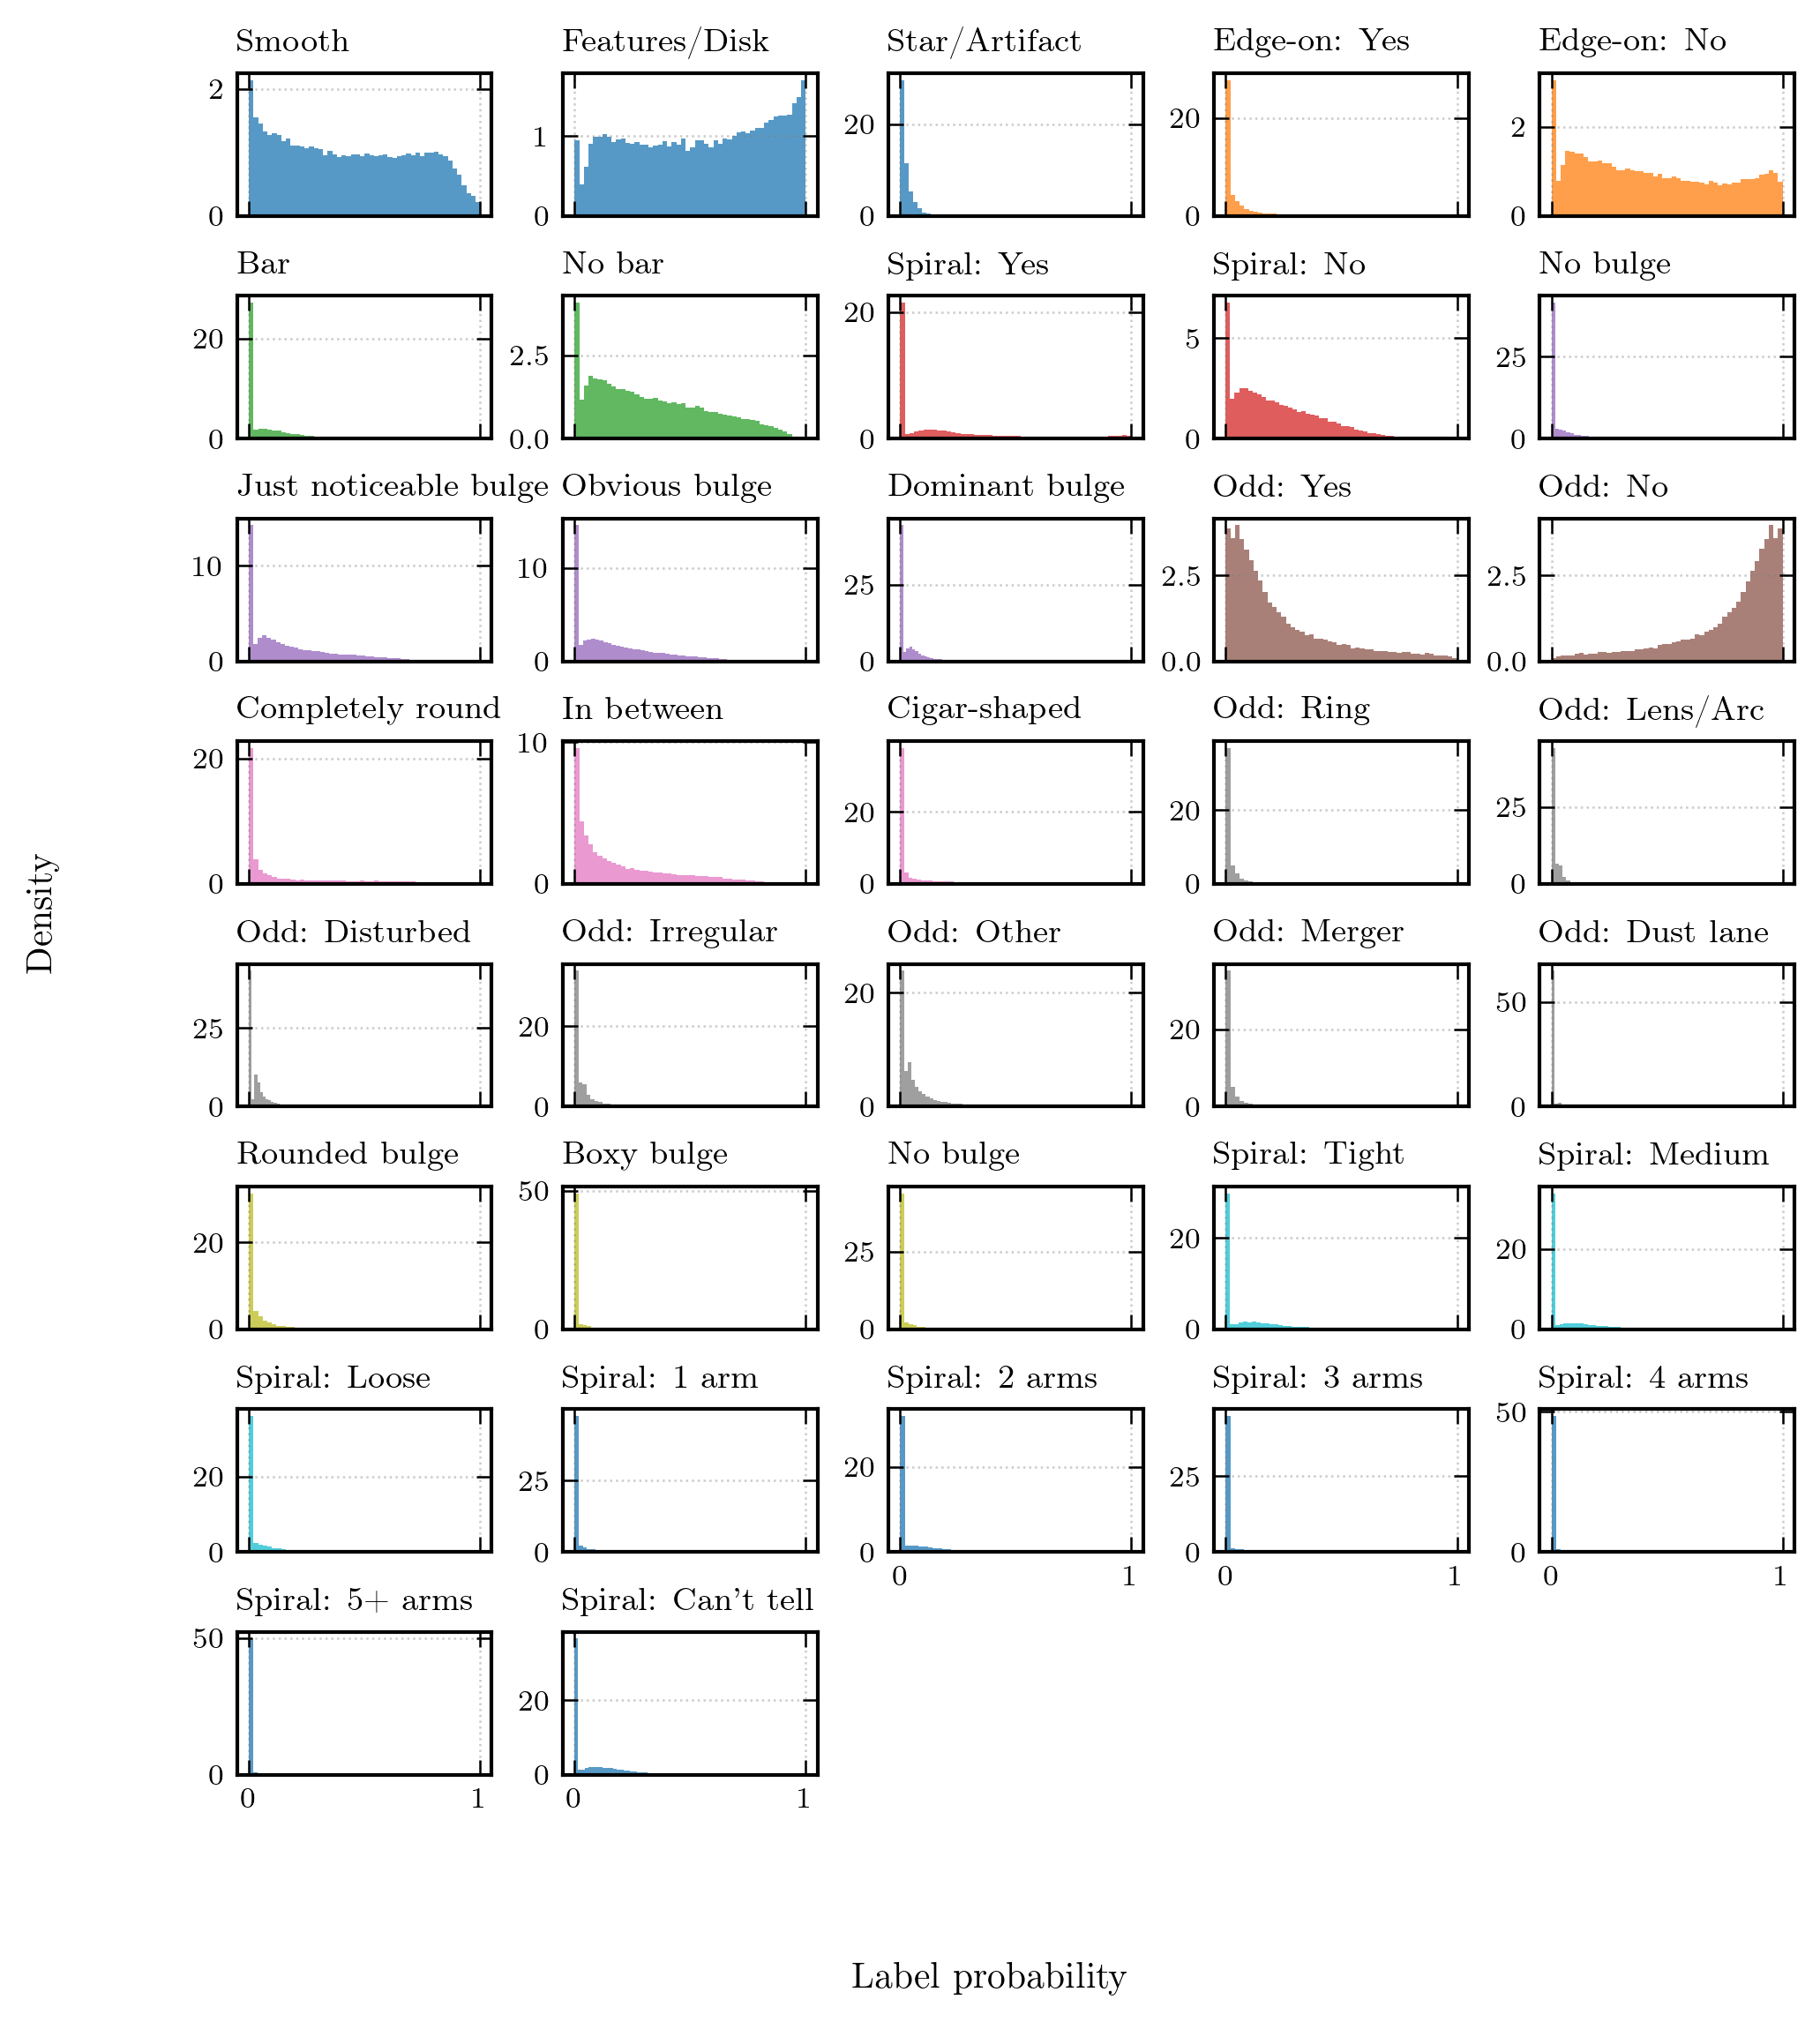

In [4]:
labels = gz.labels

axes = plotters.plot_label_distributions(labels, LABEL_COLUMNS, LABEL_DESCRIPTIVE)
plt.show()

**Commentary on distributions:**

- **Top-level labels (Class1.1--1.3)** show broad, roughly bimodal distributions -- galaxies tend to be classified as either clearly smooth or clearly featuring a disk, with fewer objects at intermediate vote fractions. This bimodality mirrors the well-known dichotomy in the galaxy population: the red sequence of pressure-supported, quiescent ellipticals and lenticulars (classified as "smooth") versus the blue cloud of rotationally-supported, star-forming disk galaxies (classified as "features/disk"). The fact that vote fractions cluster near 0 and 1 rather than sitting at intermediate values indicates strong classifier consensus and genuine morphological distinctness between these populations.
- **Deeper hierarchical labels** (e.g., Class10.x spiral tightness, Class11.x arm count) are heavily concentrated near zero. Most galaxies never reached these questions because they were classified as smooth or non-spiral. The model will need to learn that these labels are near-zero for most of the training set. Astrophysically, this reflects the fact that detailed sub-structure like arm winding angle and arm multiplicity are properties of a specific subset of galaxies -- late-type spirals (Sb--Sd) -- that constitute only a fraction of the overall population.
- **Class1.3 (Star/Artifact)** is sharply peaked at zero -- very few objects in the curated GZ2 sample are misclassified stars or artifacts, so this label will be challenging to learn from positive examples. The near-absence of stellar contaminants is a consequence of the photometric pipeline and target selection: SDSS spectroscopic targets were pre-selected to be extended sources, and the GZ2 catalog applies additional quality cuts.
- **Class8.x (Odd features)** labels are also heavily zero-concentrated, reflecting the rarity of rings, lenses, mergers, and other unusual morphologies. The merger label (Class8.6) is particularly sparse, which is astrophysically expected: galaxy--galaxy mergers are dynamically brief events ($\sim 0.5$--$1$ Gyr for the visibly disturbed phase) compared with the $\sim 10$ Gyr quiescent lifetime of a typical galaxy, so only $\sim 1$--$5\%$ of galaxies at $z < 0.25$ show merger signatures at any given time. This will be important when we estimate the merger fraction in NB 06.
- Several distributions are **bimodal** (e.g., Class6.1/6.2 -- odd yes/no), indicating clear classifier consensus. Others are **skewed** toward zero (e.g., Class5.1 -- no bulge), reflecting the predominance of bulge-dominated systems in the sample. The rarity of truly bulgeless galaxies is consistent with observations that even late-type spirals typically host pseudo-bulges formed through secular evolution of bar-driven gas inflows, and that classical bulges formed through minor mergers are ubiquitous in earlier-type systems.

### Interpretation of the label distributions

The 37 Galaxy Zoo 2 labels are vote fractions in $[0,1]$, so their histograms reflect both astrophysical morphology and the decision-tree logic of the survey. The most important point is that these quantities are not independent: many of them are conditionally defined, so strong correlations are expected and physically meaningful.

- The top-level split between **Smooth (Class1.1)**, **Features/Disk (Class1.2)**, and **Star/Artifact (Class1.3)** is the clearest separation in the data. This split closely tracks the classical Hubble sequence: smooth galaxies correspond to ellipticals (E0--E7) and lenticulars (S0), which are pressure-supported systems with little cold gas, old stellar populations, and red colors. Features/Disk galaxies correspond to spiral (Sa--Sd) and irregular (Irr) types, which are rotationally supported, gas-rich, and actively forming stars. The physical driver behind this dichotomy is ultimately the galaxy's formation history: smooth ellipticals are thought to have formed through major mergers that scramble ordered rotation into a velocity dispersion-supported spheroid, while disk galaxies assembled more quiescently through cold gas accretion and angular momentum conservation. The small Star/Artifact fraction confirms that the sample has been cleaned to focus on real galaxies.

- Many deeper labels are strongly concentrated near zero. This does not mean the feature is absent in all galaxies; it often means the question is only asked after a previous branch is selected. For example, **spiral arm count (Class11.x)** and **spiral tightness (Class10.x)** only apply to galaxies first identified as spirals. This hierarchical gating naturally produces sparse, highly imbalanced distributions. Astrophysically, arm winding angle correlates with Hubble type: Sa galaxies have tightly wound arms, Sc galaxies have loosely wound arms, following the original Hubble tuning fork. The arm count encodes whether the galaxy has grand-design structure (2 well-defined arms, often driven by density wave theory or tidal interactions) or flocculent structure (many short, patchy arm segments, driven by local gravitational instabilities in the disk).

- The negative correlations between siblings such as **smooth vs. features/disk vs. star/artifact**, **edge-on yes vs. no**, **bar vs. no bar**, and **odd yes vs. no** are expected because these are mutually exclusive answers within the same question. The anti-correlations are partly a survey-design effect, but they also reflect genuine astrophysical exclusivity: a galaxy cannot simultaneously be a featureless elliptical and a spiral disk, because these morphologies arise from fundamentally different dynamical states (dispersion-supported vs. rotation-supported).

- The positive correlation between **Features/Disk (Class1.2)** and **Spiral: Yes (Class4.1)** is physically sensible. Spiral structure requires a cold, rotationally supported stellar and gas disk in which density waves can propagate. In the Lin--Shu density wave theory, a quasi-stationary spiral pattern is maintained by the self-gravity of the disk; in the swing amplification picture, leading waves are sheared into trailing spirals by differential rotation and amplified by self-gravity. Both mechanisms require a dynamically cold, thin disk -- something that does not exist in smooth ellipticals. This is why spiral features are strongly associated with disk galaxies and are absent from spheroidal systems.

- The **bar** and **bulge** labels are also physically connected to the disk branch. Bars form through a global instability in the disk: when the disk is sufficiently massive and dynamically cold (the Toomre stability parameter $Q \lesssim 1$--$2$ for the global bar mode), the disk buckles into an elongated bar structure. Bars are efficient at redistributing angular momentum -- they funnel gas inward toward the nucleus (potentially fueling AGN or building a pseudo-bulge) and transfer angular momentum outward to the dark matter halo. The observed bar fraction of $\sim 30$% in the local universe (consistent with what we see in the GZ2 label distributions) represents a snapshot of this dynamical process: some disks are currently barred, others have dissolved their bars or have not yet formed them. Bulge prominence traces the central mass concentration and encodes the galaxy's merger and secular evolution history. **Classical bulges** are dynamically hot, round, and formed through violent relaxation in mergers (similar to small ellipticals), while **pseudo-bulges** are flatter, more disk-like, and built up slowly through bar-driven gas inflows. The bulge prominence labels thus encode a mix of formation channels.

- The **odd-feature** labels, especially **merger (Class8.6)**, are heavily concentrated near zero. This is astrophysically reasonable because the visibly disturbed phase of a galaxy merger lasts only $\sim 0.5$--$1$ Gyr (the time during which tidal tails, shells, and asymmetries are detectable), while galaxies spend $\sim 10$ Gyr in quiescent states between interactions. The merger rate at $z < 0.25$ is $\sim 0.01$--$0.05$ Gyr$^{-1}$ per galaxy, so at any given time only a small fraction of galaxies show merger signatures. Other odd features -- rings, lenses, dust lanes -- are also transient or require specific dynamical conditions (e.g., rings require Lindblad resonances with a bar; lenses may be dissolved bars).

- The **roundness** labels for smooth galaxies reflect both intrinsic three-dimensional shape and projection effects. Elliptical galaxies are triaxial systems -- they have three unequal principal axes $(a > b > c)$ -- and the observed projected ellipticity depends on the viewing angle relative to these axes. A galaxy that appears completely round could be an intrinsically spherical system (a rare oblate or prolate extreme) or a triaxial elliptical viewed along its shortest axis. Cigar-shaped objects suggest either a prolate intrinsic shape (which is physically unusual for massive ellipticals but possible for stripped remnants) or, more commonly, misclassification of an edge-on disk viewed at high inclination. This degeneracy between intrinsic shape and projection is a fundamental limitation of morphological classification from 2D imaging.

Overall, the histograms show that Galaxy Zoo labels carry real morphological information that maps onto the Hubble sequence and the underlying physical processes of galaxy formation and evolution. The strongest relationships are a combination of astrophysics and survey logic: galaxy morphology, projection, bars, bulges, spirals, and mergers all appear in the vote fractions, but only along the branches where those features are relevant. The hierarchical decision tree itself was designed to mirror the astrophysical logic of the Hubble classification -- smooth galaxies branch into roundness (elliptical sub-types), disk galaxies branch into edge-on vs. face-on, then bar, spiral, and bulge sub-types -- so the tree structure and the astrophysics reinforce each other.

## Task 7 — Prototype Images

For each of the 37 labels, we plot the image with the highest vote fraction — the "prototype" for that morphological class. This provides a visual dictionary of what each label represents and helps us anticipate which labels will be easy vs. difficult for a CNN to classify.

Labels corresponding to visually dramatic features should be straightforward for a CNN:
- **Smooth ellipticals** produce a featureless, centrally concentrated light profile that is well-described by a S\'ersic function with high index ($n \sim 4$, the de Vaucouleurs profile).
- **Edge-on disks** show a thin, elongated morphology with a characteristic dark dust lane bisecting the midplane where the interstellar medium is concentrated.
- **Grand-design spirals** (2-arm) display clear logarithmic arm patterns with blue star-forming regions tracing the density wave crests.

Labels for rare or subtle features will be much harder:
- **Lens/Arc** (Class8.2) requires detecting faint, diffuse structures that can be confused with tidal streams or PSF artifacts.
- **Dust lane** (Class8.7) is a narrow, dark absorption feature that is only prominent in edge-on systems and easily lost at low resolution.
- **Merger** (Class8.6) signatures — tidal tails, shells, asymmetric isophotes — span a wide range of morphologies depending on the merger stage (first passage, coalescence, post-merger), mass ratio (major vs. minor), and gas fraction, making it difficult to learn a single "merger template."

In [5]:
# Load all images for prototype display (we need the full set to find max-label images)
# This may take a few minutes for large datasets; results are used again in NB 02.
gz_images = GalaxyZooImages(
    source=gz,
    image_dir=IMAGE_DIR,
    crop_fraction=0.25,  # match the NB 02 / model preprocessing pipeline
    target_size=96,      # 96x96 center crop — what the CNN actually sees
)
print(f"Images loaded: {gz_images.images.shape}")

Loading images: 100%|██████████| 61578/61578 [01:20<00:00, 767.55it/s] 

Images loaded: (61578, 96, 96, 3)


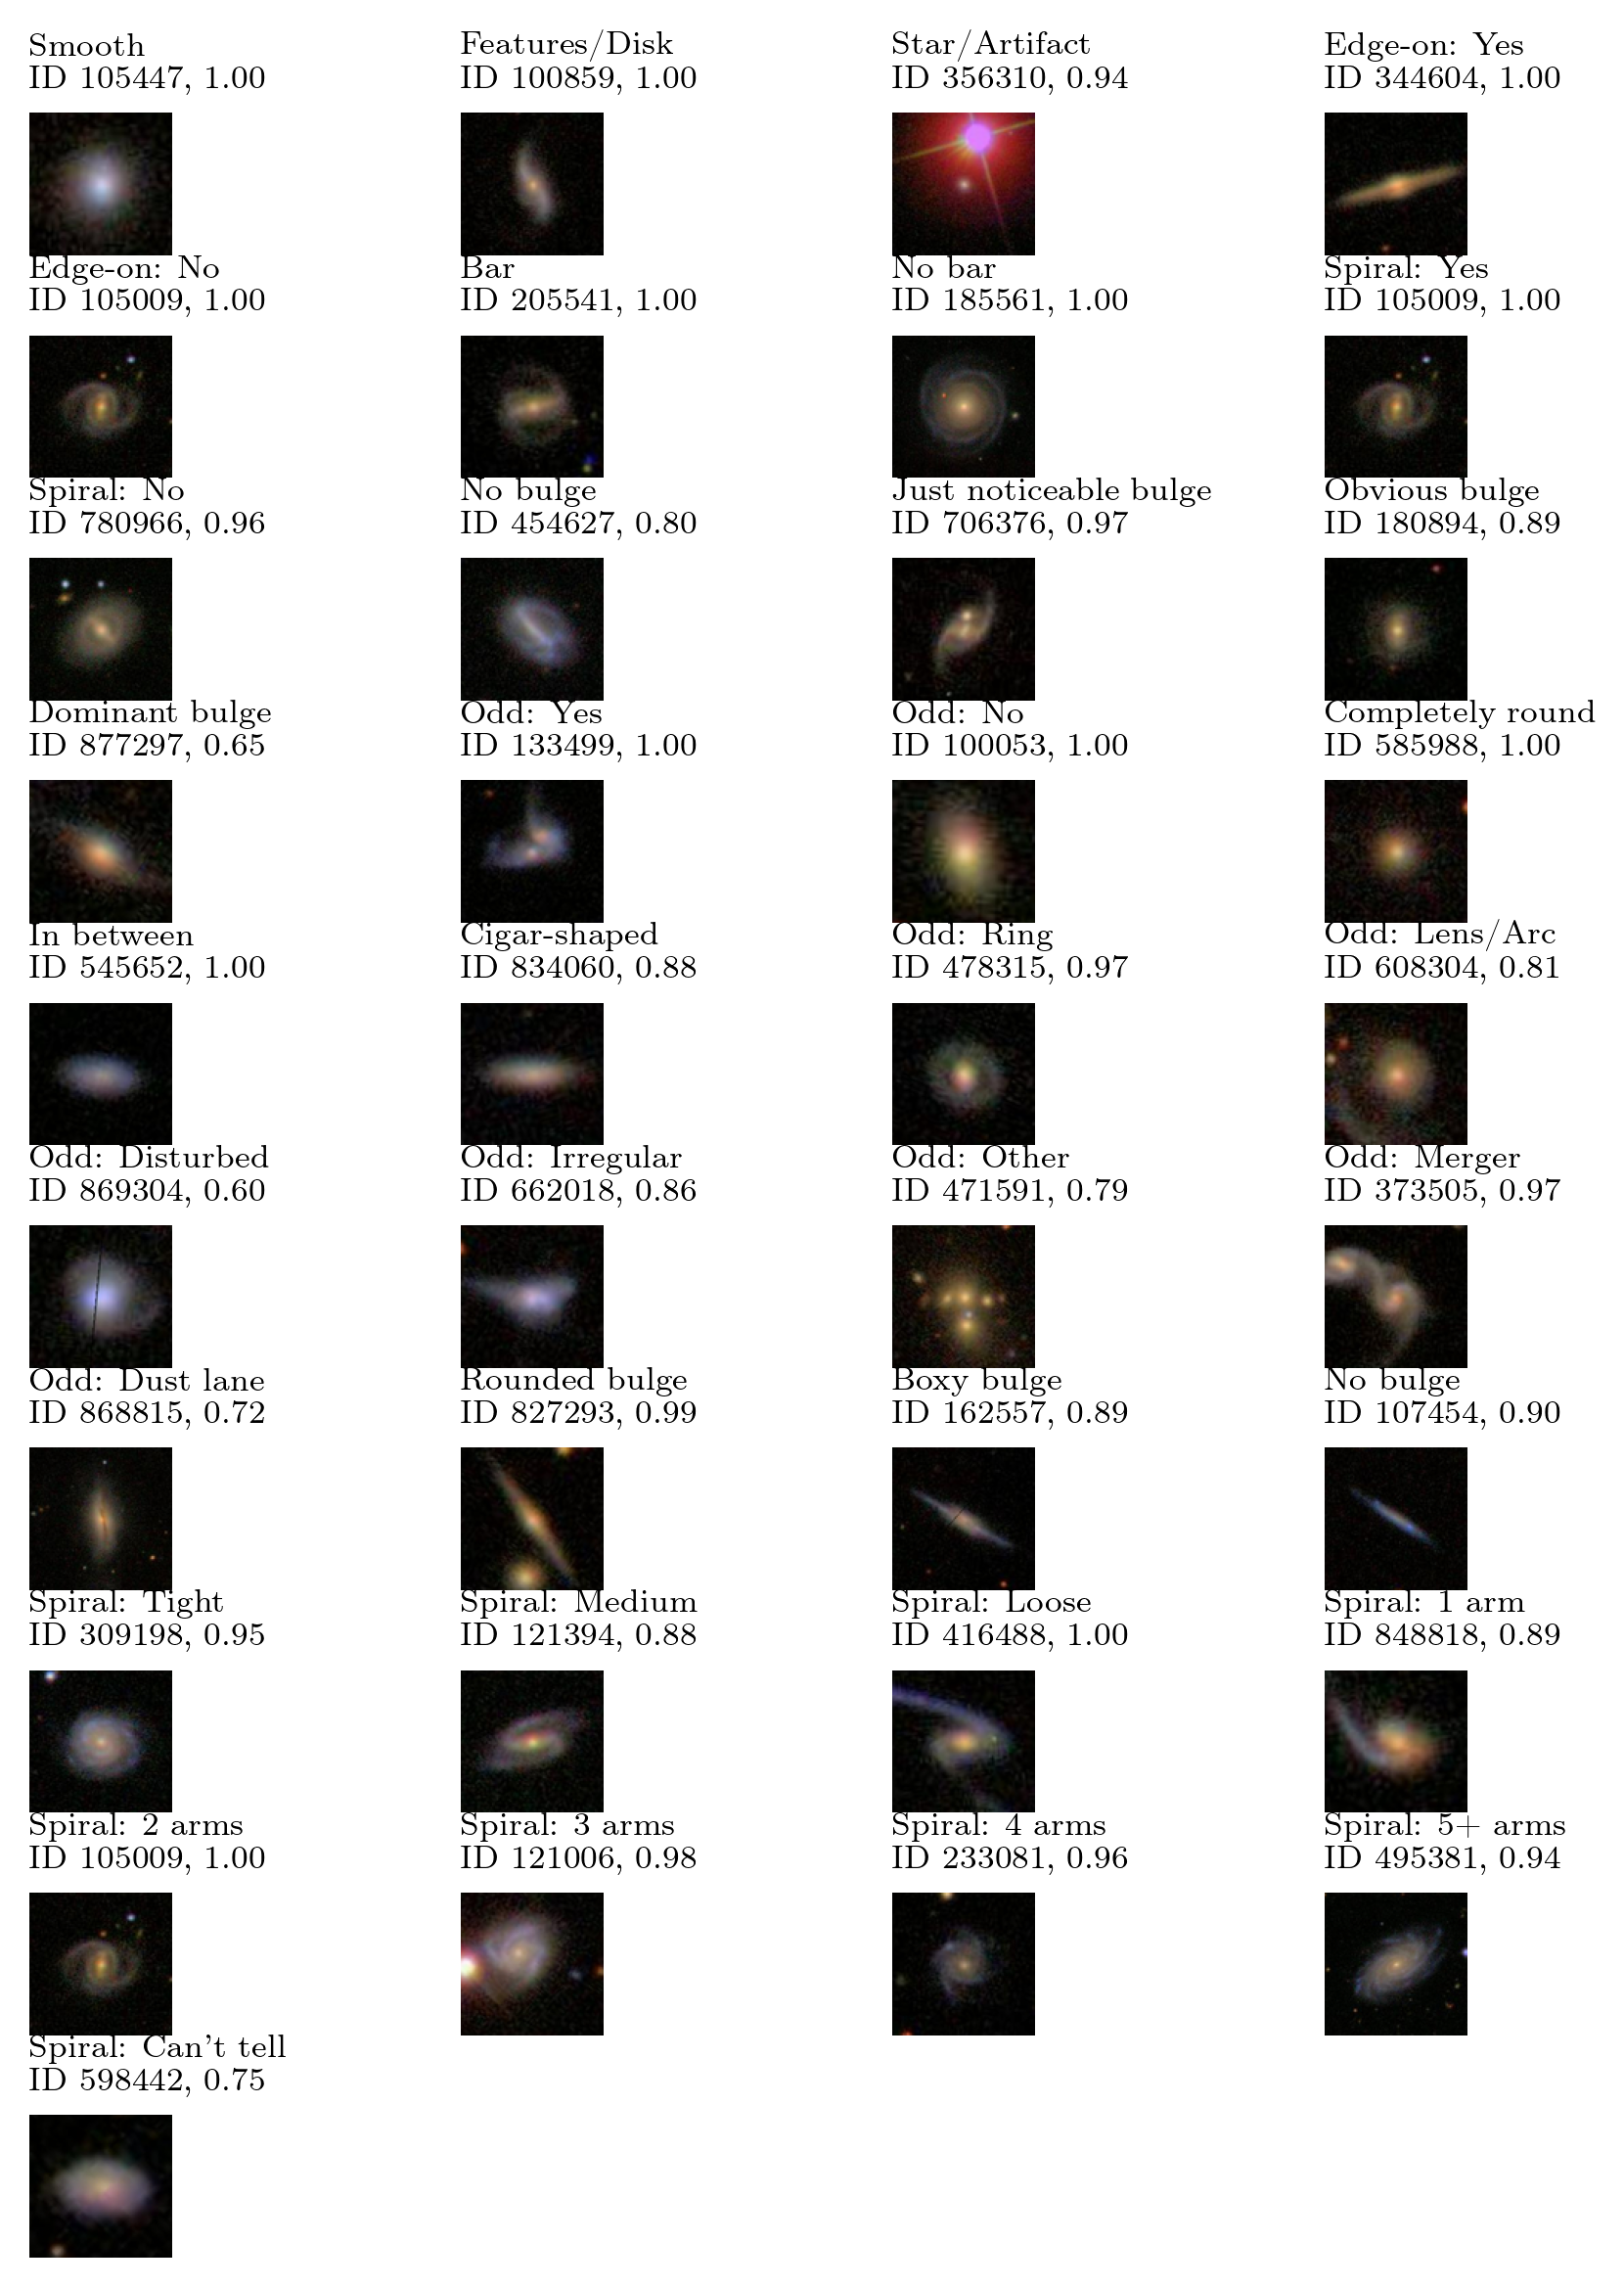

In [6]:
axes = plotters.plot_prototype_images(
    gz_images.images, gz.galaxy_ids, labels, LABEL_COLUMNS, LABEL_DESCRIPTIVE,
)
plt.show()

## Task 8 — Correlation Matrix

We compute the Pearson correlation coefficient between every pair of labels using the formula from the lab manual (Equation 1):

$$\rho_{ij} = \frac{\langle ij \rangle - \langle i \rangle \langle j \rangle}{\sqrt{\langle i^2 \rangle - \langle i \rangle^2}\sqrt{\langle j^2 \rangle - \langle j \rangle^2}}$$

where angle brackets denote averages over all galaxies. This is the standard Pearson correlation coefficient, measuring linear association between labels.

We display the $37 \times 37$ correlation matrix with labels reordered by their position in the GZ2 decision tree, so that within-question siblings and parent–child branches form contiguous blocks. Tick labels are colored by branch (gray = root, red = smooth, orange = edge-on, green = face-on/bar, blue = spiral, purple = bulge, brown = odd) to make the hierarchical structure visually explicit.

**Expected patterns:**
- **Mutually exclusive labels within a question** should have $\rho \approx -1/(k-1)$ where $k$ is the number of answer options, if galaxies vote cleanly for one option. For binary questions (e.g., Class2.1 vs Class2.2), this gives $\rho \approx -1$.
- **Parent-child relationships** in the hierarchical tree should produce positive correlations: if most galaxies answering "features/disk" also answer "spiral: yes," then Class1.2 and Class4.1 will be positively correlated.
- **Labels at different levels** with no logical connection should have $\rho \approx 0$.

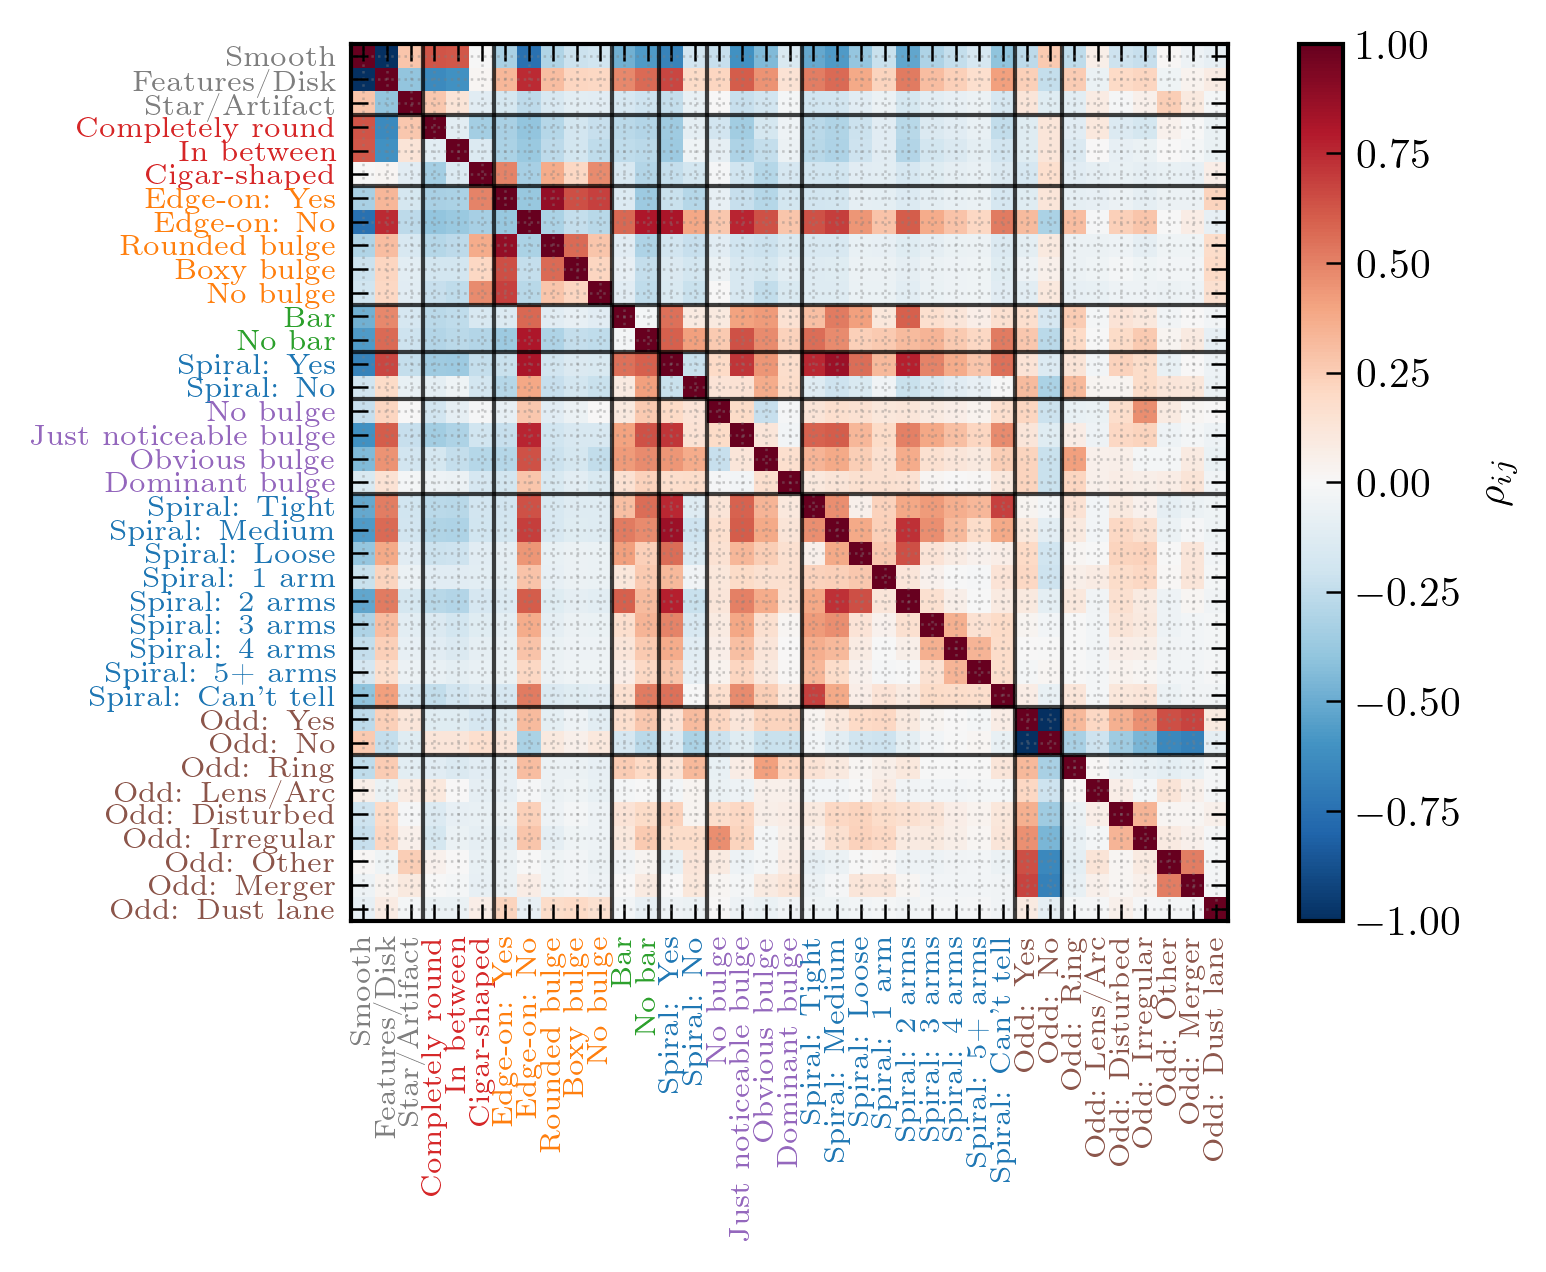

In [7]:
# Compute correlation matrix using the lab manual formula
mean_i = np.mean(labels, axis=0)           # (37,)
mean_ij = labels.T @ labels / len(labels)  # (37, 37)
mean_i2 = np.mean(labels ** 2, axis=0)     # (37,)

numerator = mean_ij - np.outer(mean_i, mean_i)
denominator = np.sqrt(np.outer(mean_i2 - mean_i ** 2, mean_i2 - mean_i ** 2))

# Avoid division by zero for constant labels
with np.errstate(invalid="ignore"):
    corr_matrix = np.where(denominator > 0, numerator / denominator, 0.0)

label_desc_list = [LABEL_DESCRIPTIVE[col] for col in LABEL_COLUMNS]
ax = plotters.plot_hierarchical_correlation(
    corr_matrix, label_desc_list, LABEL_TREE, LABEL_COLUMNS,
)
plt.show()

**Commentary on the correlation matrix:**

- **Strong negative correlations** along the anti-diagonal blocks confirm mutually exclusive categories within each question. For example, Class1.1 (Smooth) and Class1.2 (Features/Disk) have $\rho \approx -0.99$, close to the theoretical $-1$ for a two-dominant-option question (Class1.3 is nearly always zero, so the binary approximation holds). This near-perfect anti-correlation reflects the astrophysical reality that the smooth/disk dichotomy is the dominant axis of morphological variation in the galaxy population — it separates the red sequence from the blue cloud, pressure-supported kinematics from rotation-supported kinematics, and quiescent stellar populations from star-forming ones.
- **Strong positive correlations** between parent and child labels follow the hierarchical tree: Class1.2 (Features/Disk) correlates positively with Class4.1 (Spiral: Yes), which in turn correlates with Class11.x (arm count labels). This cascade is astrophysically causal: spiral arms are a disk instability phenomenon — they cannot exist without a rotationally-supported disk, and their detailed properties (winding angle, arm count) are set by the disk's mass, angular momentum profile, and interaction history.
- **Smooth (Class1.1) anti-correlates with all disk sub-questions** (bar, spiral, bulge prominence) — as expected, since smooth galaxies skip the entire disk branch of the decision tree. Physically, this means that elliptical galaxies genuinely lack the ordered rotation, cold gas, and thin disk geometry that produce bars, spirals, and disk-embedded bulges. The anti-correlations are not just a gating artifact but reflect the deep structural differences between these galaxy families.
- **Labels that encode rare astrophysical states**: Class8.x (odd features) labels show weak correlations with most other labels, reflecting the rarity and physical diversity of these phenomena. A ring galaxy, a merger remnant, and a galaxy with a prominent dust lane have almost nothing in common morphologically or dynamically — they are grouped together only because they are all "unusual" relative to the Hubble sequence. This heterogeneity makes the odd-feature branch the hardest part of the classification for a CNN.
- Some labels are **less reliable** than others: labels deeper in the tree (e.g., spiral tightness, arm count) are noisier because fewer classifiers saw them (the questions are only triggered along the spiral branch), and the smaller effective sample sizes produce higher variance in the vote fractions. Additionally, arm winding and arm count are intrinsically harder to judge visually than top-level morphology, especially at the modest angular resolution of SDSS imaging ($\sim 1.4''$ seeing).

### Detailed trends in the correlation matrix

#### 1. Within-question anti-correlations (mutually exclusive answers)

The strongest negative correlations occur between sibling answers within the same question, exactly as the decision-tree design predicts:

- **Odd: Yes vs Odd: No** (Class6.1 vs 6.2): $\rho = -1.000$. This is a strict binary — every galaxy gets an odd-or-not vote, and the two fractions sum to unity by construction.
- **Smooth vs Features/Disk** (Class1.1 vs 1.2): $\rho = -0.992$. Nearly perfectly anti-correlated because Class1.3 (Star/Artifact) is almost always zero, making Q1 effectively binary. A galaxy classified as smooth is almost never classified as having disk features, and vice versa.

These near-$-1$ correlations are largely a *survey design* effect rather than an astrophysical discovery: they follow from the constraint that vote fractions within a question sum to the parent fraction. However, the sharpness of the anti-correlation — $\rho$ close to $-1$ rather than, say, $-0.5$ — indicates that classifiers reach strong consensus, which in turn reflects the fact that the smooth/disk distinction maps onto a genuine bimodality in galaxy structure (the E/S0 vs. Sa--Irr divide on the Hubble tuning fork).

#### 2. Parent–child positive correlations (hierarchical gating)

Positive correlations trace the decision-tree inheritance. A child label can only be nonzero if its parent was selected, so parent and child are positively correlated:

| Parent | Child | $\rho$ |
|--------|-------|--------|
| Features/Disk (1.2) | Edge-on: No (2.2) | $+0.748$ |
| Features/Disk (1.2) | Spiral: Yes (4.1) | $+0.672$ |
| Edge-on: Yes (2.1) | Rounded bulge (9.1) | $+0.879$ |
| Edge-on: Yes (2.1) | No bulge (9.3) | $+0.682$ |
| Spiral: Yes (4.1) | Medium winding (10.2) | $+0.858$ |
| Spiral: Yes (4.1) | 2 arms (11.2) | $+0.781$ |
| Spiral: Yes (4.1) | Tight winding (10.1) | $+0.754$ |
| Smooth (1.1) | Completely round (7.1) | $+0.629$ |
| Smooth (1.1) | In between (7.2) | $+0.617$ |
| Odd: Yes (6.1) | Merger (8.6) | $+0.672$ |

These are physically sensible: spiral tightness and arm count only exist for spirals; roundness only exists for smooth galaxies; edge-on bulge shape only exists for edge-on disks. The strongest parent–child correlation is **Edge-on: Yes $\to$ Rounded bulge** ($\rho = +0.879$), meaning that when classifiers identify an edge-on disk, they overwhelmingly also identify a rounded (rather than boxy) central bulge. This is astrophysically interesting: boxy bulges are generally associated with the vertically buckled inner region of a bar viewed side-on, while rounded (peanut/disky) bulges are seen in unbarred edge-on disks or barred disks viewed end-on. The dominance of rounded bulge classifications suggests either that most edge-on GZ2 disks are unbarred, or that the SDSS resolution is insufficient for classifiers to distinguish boxy from rounded isophotes — the boxy/peanut shape typically requires careful isophotal analysis at higher resolution.

An asymmetry worth noting: **Features/Disk correlates much more strongly with Edge-on: No** ($\rho = +0.748$) **than with Edge-on: Yes** ($\rho = +0.333$). This means the majority of disk galaxies in this sample are *face-on or moderately inclined*, not edge-on — consistent with geometric projection. For a randomly oriented thin disk, the probability of appearing within inclination $i$ of edge-on ($i = 90°$) scales as $\cos i$, so truly edge-on views ($i > 80°$) subtend only $\sim 17\%$ of the solid angle. The observed asymmetry in the correlations matches this geometric expectation.

#### 3. Smooth vs the entire disk branch

Smooth (Class1.1) anti-correlates with every label in the disk sub-tree, confirming that the two morphological families are well-separated:

- Strongest: vs Edge-on: No ($\rho = -0.746$), vs Spiral: Yes ($\rho = -0.671$), vs Just noticeable bulge ($\rho = -0.605$), vs Medium winding ($\rho = -0.568$), vs 2 arms ($\rho = -0.519$).
- The anti-correlations weaken as you go deeper into the tree (e.g., vs Spiral: Loose is only $-0.384$, vs 1 arm is $-0.224$), because deeper labels are sparser — most galaxies have near-zero values regardless of whether they are smooth or disk, diluting the linear correlation.

The gradient of anti-correlation strength with tree depth is itself informative: it tells us that the smooth/disk divide is the *primary* axis of morphological variation, and that sub-classifications like arm count and winding angle are *secondary* axes that explain progressively less variance. This is consistent with the Hubble sequence, where the E/S distinction is the coarsest division and the Sa/Sb/Sc sub-types refine it along a continuous sequence of decreasing bulge-to-total ratio and increasing gas fraction.

#### 4. The spiral–bulge connection

**Just noticeable bulge** (Class5.2) shows surprisingly strong positive correlations with spiral labels: $\rho = +0.713$ with Spiral: Yes, $\rho = +0.637$ with No bar, $\rho = +0.402$ with Bar. This reflects a physical trend: galaxies with prominent spiral structure tend to be late-type disks (Sb--Sc) with small bulge-to-total ratios ($B/T \sim 0.1$--$0.3$). In contrast, **Dominant bulge** (Class5.4) has weaker correlations with spiral structure ($\rho = +0.176$), consistent with the observation that bulge-dominated systems (Sa/S0) have less prominent arms — the high central mass concentration suppresses the disk self-gravity that drives spiral instabilities, and the dominance of the bulge's hot stellar component over the disk's cold component stabilizes the system against large-scale pattern formation.

The **bar–bulge** correlation is also physically interesting: Bar correlates most with Obvious bulge ($\rho = +0.429$) and Just noticeable bulge ($\rho = +0.402$), but weakly with No bulge ($\rho = +0.099$) and Dominant bulge ($\rho = +0.153$). This "Goldilocks" pattern reflects the dynamics of bar formation. A bar requires the disk to be massive enough relative to the halo and bulge for the global $m = 2$ instability to grow — but if the central mass concentration is too high (dominant bulge), the inner Lindblad resonance moves outward and truncates or prevents bar formation. Conversely, truly bulgeless disks may lack the central mass needed to seed the instability efficiently. The sweet spot for bar formation is intermediate $B/T$, which is exactly what the correlations show. N-body simulations by Athanassoula (2003) and Debattista et al. (2006) confirm this picture: bars form most readily in disks with moderate central concentrations, and bar strength anti-correlates with bulge dominance.

#### 5. Spiral tightness vs arm count

Within the spiral sub-tree, tightness and arm count are correlated in a physically meaningful way:

- **Medium winding $\times$ 2 arms**: $\rho = +0.731$ — the classic grand-design spiral (e.g., M51, M81) dominates the sample. Grand-design spirals are thought to be driven by either a quasi-stationary density wave (Lin & Shu 1964) or by tidal interactions with companion galaxies. The 2-arm pattern corresponds to the dominant $m = 2$ Fourier mode of the disk's gravitational potential.
- **Loose winding $\times$ 2 arms**: $\rho = +0.646$ — open two-armed spirals are also common, corresponding to Sc--Sd galaxies on the Hubble sequence. These systems have lower mass, lower central concentration, and higher gas fractions than their tightly-wound counterparts.
- **Tight winding $\times$ Can't tell**: $\rho = +0.681$ — tightly wound spirals are harder to resolve into discrete arms at SDSS resolution ($\sim 1.4''$ seeing, corresponding to $\sim 1$--$3$ kpc at typical GZ2 redshifts), so classifiers often cannot determine arm count. This is a *measurement limitation*, not an astrophysical correlation. It suggests that the CNN may also struggle with arm count prediction for tightly wound systems.
- **Tight winding $\times$ 3+ arms**: $\rho \approx 0.33$--$0.43$ — tightly wound multi-arm spirals correspond to flocculent galaxies, where spiral structure is driven by local swing amplification and stochastic star formation rather than a global density wave. Flocculent spirals (e.g., NGC 2841) produce many short, patchy arm segments that appear "tightly wound" because the individual segments subtend small azimuthal angles.
- **Loose winding $\times$ 3+ arms**: $\rho < 0.14$ — loose multi-arm spirals are rare, consistent with theoretical expectations: loose winding requires low central mass concentration (high shear), but multi-arm structure requires a disk that is gravitationally unstable at multiple azimuthal wavenumbers simultaneously. These conditions are physically difficult to satisfy together.

#### 6. The Cigar-shaped anomaly

**Cigar-shaped** (Class7.3) is nominally a sub-label of Smooth (Q7 is only asked when Q1 = Smooth), yet it correlates *positively* with **Edge-on: Yes** ($\rho = +0.496$) and with edge-on bulge labels (**Rounded bulge** $\rho = +0.370$, **No bulge** $\rho = +0.475$). This reveals a systematic classification confusion: highly inclined disk galaxies, when viewed at $i \gtrsim 80°$, can appear as featureless, elongated objects with no visible spiral structure or dust lane — especially at low surface brightness or low resolution. Some classifiers interpret these as "smooth + cigar-shaped" rather than "features/disk + edge-on," because the disk sub-structure is not resolved.

The near-zero correlation between Smooth and Cigar ($\rho = -0.001$) confirms that cigar-shaped galaxies are *not* typical smooth ellipticals — they occupy a distinct region of morphological space. True prolate (cigar-shaped) ellipticals are in fact extremely rare in the local universe; most ellipticals are oblate or mildly triaxial. The Cigar label is therefore predominantly picking up misclassified edge-on disks rather than a genuine population of prolate spheroids. This has implications for the CNN: the model should learn that elongated, featureless objects are more likely to be edge-on disks than prolate ellipticals.

#### 7. Odd features: rare but structured

The odd-feature labels (Class8.x) are sparse but show interpretable patterns that connect to specific astrophysical mechanisms:

- **Merger** (Class8.6) anti-correlates with Odd: No ($\rho = -0.672$) and weakly correlates with Spiral: No ($\rho = +0.113$). During the coalescence phase of a major merger, the strong tidal field disrupts pre-existing disk structure (including spiral arms), producing shells, streams, and asymmetric isophotes instead. The positive correlation with "no spiral" is consistent with the morphological transformation pathway: major mergers destroy disk morphology and can transform spirals into ellipticals (the "merger hypothesis" for elliptical galaxy formation, Toomre & Toomre 1972).
- **Dust lane** (Class8.7) correlates with Edge-on: Yes ($\rho = +0.226$). Dust lanes are the projected midplane of a disk galaxy's interstellar medium (ISM). The ISM is confined to a thin layer ($h_z \sim 100$--$300$ pc) by the gravitational potential of the disk, so dust absorption is strongest when the line of sight passes through this layer edge-on. At lower inclinations, the dust is distributed across the face of the galaxy and produces diffuse reddening rather than a sharp lane.
- **Ring** (Class8.1) correlates with Spiral: No ($\rho = +0.323$) and Bar ($\rho = +0.252$). Ring galaxies in the GZ2 sample are predominantly *resonance rings* — gas accumulations at the inner and outer Lindblad resonances (ILR, OLR) of a bar pattern. The bar drives gas inward past the corotation radius; at the ILR, gas piles up into a nuclear ring, and at the OLR, into an outer ring. These rings replace or suppress grand-design spiral structure because the bar's gravitational torque organizes the gas into closed orbits at resonances rather than allowing it to form open spiral arms. Collisional ring galaxies (e.g., the Cartwheel, produced by a head-on galaxy collision) are a different, much rarer phenomenon.
- **Disturbed** and **Irregular** (Class8.3, 8.4) both positively correlate with Features/Disk ($\rho \approx +0.2$). Disturbed morphologies are more common in gas-rich disk systems because tidal interactions and minor mergers are more visible in a thin disk (which is easily warped and distorted) than in a hot, kinematically smooth spheroid (which responds weakly to perturbations). Irregular galaxies are often low-mass, gas-rich systems with chaotic star formation and no organized disk or spiral structure — they sit at the low-mass end of the blue cloud.

#### 8. Roundness labels and the intrinsic shape distribution

The Q7 roundness labels (Completely round, In between, Cigar-shaped) — nominally only for smooth galaxies — show strong cross-correlations with the rest of the matrix:

- **Completely round** and **In between** are strongly positive with Smooth ($\rho \approx +0.62$) and strongly negative with Features/Disk ($\rho \approx -0.62$), confirming they are correctly gated.
- Both anti-correlate with all spiral/bar/bulge labels at $\rho \approx -0.2$ to $-0.4$, acting as a "not-a-disk" signal.
- **Cigar-shaped** breaks this pattern: it anti-correlates with Smooth ($\rho \approx 0$) but positively correlates with Edge-on: Yes ($\rho = +0.496$), acting more like an edge-on indicator than a smooth-galaxy sub-type.

The distribution of roundness labels within the smooth population encodes information about the intrinsic 3D shape distribution of elliptical galaxies, convolved with random viewing angles. Statistical deprojection studies (e.g., Padilla & Strauss 2008) show that massive ellipticals are mildly triaxial with axis ratios $b/a \sim 0.8$--$0.9$ and $c/a \sim 0.6$--$0.8$, which projects to a broad distribution of apparent ellipticities. The "Completely round" label preferentially selects galaxies viewed face-on along the short axis (or intrinsically near-spherical systems), while "In between" captures the bulk of the mildly elliptical population. The CNN will need to learn that roundness carries information about 3D shape even though the images are 2D projections.

### Diagnostic plots to explore further

Building on the label distributions, prototypes, and correlation matrix, the following plots would deepen our understanding of the data before training:

1. **Hierarchical label tree heatmap** — Instead of showing all $37 \times 37$ correlations, group labels by their parent question and display block-diagonal sub-matrices. This would visually isolate the within-question anti-correlations from the cross-branch correlations, making the tree structure explicit.

2. **t-SNE or UMAP of the 37-dimensional label space** — Embed the 61,578 galaxies into 2D using their label vectors. Color points by top-level class (smooth vs. features vs. star). This reveals whether the label space has natural clusters, continuous gradients, or isolated outlier populations — information that could guide the choice of loss function (MSE vs. classification).

3. **Label-conditional image montages** — For each of the strongest correlation pairs (e.g., Spiral: Yes + Medium winding + 2 arms), display $3 \times 3$ grids of galaxies in the high-high, high-low, low-high, and low-low quadrants. This would visually confirm whether the correlations correspond to morphologically distinct populations or are artifacts of the vote-fraction encoding.

4. **Pairwise scatter plots of correlated labels** — Plot label $i$ vs label $j$ for the strongest positive and negative correlations (e.g., Features/Disk vs Edge-on: No, Spiral: Yes vs Medium winding). Overlay density contours to reveal whether the relationship is linear, bimodal, or has a floor/ceiling structure from the hierarchical gating.

5. **Effective sample size per label** — Since deeper labels are gated by parent answers, the number of galaxies with nonzero values varies dramatically across labels. A bar chart of $N_{\text{eff}} = \sum_k \mathbb{1}[y_k > 0.1]$ per label would quantify the class imbalance the CNN must handle and identify which labels will have the poorest training signal.

6. **Principal component analysis (PCA) of the label matrix** — Compute the eigenspectrum of the $37 \times 37$ correlation matrix. The number of eigenvalues above 1 (Kaiser criterion) tells us the effective dimensionality of the label space — likely much less than 37 given the hierarchical constraints. The leading eigenvectors would reveal the dominant axes of morphological variation (likely smooth-vs-disk, edge-on-vs-face-on, spiral-vs-not).

7. **Pixel intensity statistics** — Histograms of mean pixel brightness, contrast (standard deviation), and color ratios ($g/r$, $r/i$) across the image set, split by top-level morphology. Smooth ellipticals tend to be redder and more centrally concentrated than blue spirals — if this is visible in raw pixel statistics, it suggests the CNN has an easy low-level shortcut for the top-level classification.

## Task 9 — Memory Estimation

Before loading all images, we estimate the memory required. Each JPEG image is $H \times W \times 3$ pixels (RGB). When loaded as float32, each pixel takes 4 bytes. The total memory for $N$ images is:

$$\text{Memory (bytes)} = N \times H \times W \times 3 \times 4$$

We estimate this from the first image's dimensions and the total number of galaxies. At the raw $424 \times 424$ size the $61{,}578$-galaxy training set is $\sim 133$ GB as `float32` — far too large to hold in memory on the local workstation used for this lab (an NVIDIA RTX 5070 Ti laptop GPU with $12$ GB VRAM, exposed to a WSL2 environment with $24$ GB of system RAM allocated). The compression step in NB 02 is therefore motivated not by a hard quota imposed by a shared computing environment, but by the *practical* memory budget of the local machine: we need the entire preprocessed dataset to be GPU-resident so that training can iterate at $\sim 3$ s/epoch on the Custom CNN without ever touching disk between epochs.

The choice of $96 \times 96$ as the model input (cached at $136 \times 136$ for rotation slack — see NB 02) is **quality-driven** rather than memory-driven: it is the smallest size that still resolves the morphological features the 37 GZ2 questions actually depend on (spiral-arm pitch, bar elongation, edge-on dust lanes, bulge prominence) at SDSS's typical $\sim 1.4''$ seeing. The full preprocessed cache happens to fit comfortably in $\sim 3.4$ GB on disk as `uint8` and $\sim 13.7$ GB in float32 once on the GPU — well within the $12$ GB VRAM budget once we use the `uint8`-resident pathway in NB 02. If memory were the binding constraint we could go smaller, but the quality–compute trade-off would degrade the deep-tree label predictions (arm count in particular), so we stay deliberately loose on the rescaling.

In [8]:
# Memory estimation
example_img = _load_image(IMAGE_DIR / f"{gz.galaxy_ids[0]}.jpg")
h, w, c = example_img.shape
bytes_per_image = h * w * c * 4  # float32

total_bytes = len(gz) * bytes_per_image
total_gb = total_bytes / 1e9

print(f"Image dimensions: {h} x {w} x {c}")
print(f"Bytes per image (float32): {bytes_per_image:,}")
print(f"Total pixels: {len(gz) * h * w:,}")
print(f"Total memory for {len(gz)} images: {total_gb:.1f} GB")
print(f"\nThis exceeds the 24 GB system RAM (WSL2) and 12 GB VRAM (RTX 5070 Ti laptop GPU)")
print(f"of the local workstation, so the images are cropped and resampled to 136x136")
print(f"in NB 02 (~13.7 GB float32 / ~3.4 GB uint8 on disk).")

Image dimensions: 424 x 424 x 3
Bytes per image (float32): 2,157,312
Total pixels: 11,070,246,528
Total memory for 61578 images: 132.8 GB

This exceeds the 24 GB system RAM (WSL2) and 12 GB VRAM (RTX 5070 Ti laptop GPU)
of the local workstation, so the images are cropped and resampled to 136x136
in NB 02 (~13.7 GB float32 / ~3.4 GB uint8 on disk).


### Save labels for downstream notebooks

In [9]:
_labels_npz = Path("artifacts/galaxy_zoo_labels.npz")
if _labels_npz.exists():
    print(f"Skipping save: {_labels_npz} already exists")
else:
    _labels_npz.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        _labels_npz,
        galaxy_ids=gz.galaxy_ids,
        labels=labels,
        label_names=np.array(LABEL_COLUMNS),
        corr_matrix=corr_matrix,
    )
    print("Saved artifacts/galaxy_zoo_labels.npz")
    print(f"  galaxy_ids: {gz.galaxy_ids.shape}")
    print(f"  labels: {labels.shape}")
    print(f"  corr_matrix: {corr_matrix.shape}")

Skipping save: artifacts/galaxy_zoo_labels.npz already exists


In [10]:
summary = pd.DataFrame([
    {"quantity": "N galaxies (training)",       "value": int(len(gz))},
    {"quantity": "N labels (decision-tree leaves)", "value": int(N_LABELS)},
    {"quantity": "Raw image H × W × C",          "value": f"{h} × {w} × {c}"},
    {"quantity": "Float32 bytes per raw image",  "value": int(bytes_per_image)},
    {"quantity": "Raw float32 footprint",        "value": f"{total_gb:.1f} GB"},
    {"quantity": "Median votes per galaxy (W13)", "value": "~40–50"},
    {"quantity": "GZ2 parent sample (W13)",      "value": "304,122"},
])
summary


,quantity,value
0,N galaxies (training),61578
1,N labels (decision-tree leaves),37
2,Raw image H × W × C,424 × 424 × 3
3,Float32 bytes per raw image,2157312
4,Raw float32 footprint,132.8 GB
5,Median votes per galaxy (W13),~40–50
6,GZ2 parent sample (W13),"304,122"


### Dataset summary

A compact summary of what the rest of the notebooks consume.